In [33]:
import pandas as pd
path = "../data/datasets/enhanced_student_habits_performance_dataset/enhanced_student_habits_performance_dataset.csv"
performance = pd.read_csv(path)
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

In [34]:
performance.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [35]:
performance.describe()

,student_id,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,previous_gpa,semester,stress_level,social_activity,screen_time,parental_support_level,motivation_level,exam_anxiety_score,time_management_score,exam_score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,139999.500000,22.004288,4.174388,2.501366,1.997754,69.967884,7.017418,3.516587,6.804108,3.602448,4.497338,5.012478,2.500225,9.673029,5.479438,5.488525,8.508475,5.499132,89.141350
std,23094.155105,3.745570,2.004135,1.445441,1.155992,17.333015,1.467377,2.291575,1.921579,0.462876,2.295312,1.953174,1.704292,2.780869,2.873327,2.867782,1.796411,2.603534,11.591497
min,100000.000000,16.000000,0.000000,0.000000,0.000000,40.000000,4.000000,0.000000,1.000000,1.640000,1.000000,1.000000,0.000000,0.300000,1.000000,1.000000,5.000000,1.000000,36.000000
25%,119999.750000,19.000000,2.800000,1.200000,1.000000,55.000000,6.000000,2.000000,5.500000,3.270000,2.000000,3.600000,1.000000,7.800000,3.000000,3.000000,7.000000,3.200000,82.000000
50%,139999.500000,22.000000,4.125624,2.500000,2.000000,69.900000,7.000000,4.000000,6.900000,3.790000,5.000000,5.000000,2.000000,9.700000,5.000000,5.000000,10.000000,5.500000,93.000000
75%,159999.250000,25.000000,5.500000,3.800000,3.000000,84.900000,8.000000,6.000000,8.200000,4.000000,7.000000,6.400000,4.000000,11.600000,8.000000,8.000000,10.000000,7.800000,100.000000
max,179999.000000,28.000000,12.000000,5.000000,4.000000,100.000000,12.000000,7.000000,10.000000,4.000000,8.000000,10.000000,5.000000,21.000000,10.000000,10.000000,10.000000,10.000000,100.000000


## Note to self:.
Prepare a pipeline for the transformation that will happen to the data

In [36]:
def check_proportions(train, test, stratum):
    print("train,", train[stratum].value_counts() / len(train))
    print("Test,", test[stratum].value_counts() / len(test))

In [54]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(performance, performance["major"]):
    strat_train_set = performance.loc[train_index]
    strat_test_set = performance.loc[test_index]
    
performance_df = strat_train_set.copy()    

In [38]:
check_proportions(strat_train_set, strat_test_set, "major")

train, major
Arts                0.168813
Psychology          0.167953
Computer Science    0.166906
Business            0.165953
Engineering         0.165359
Biology             0.165016
Name: count, dtype: float64
Test, major
Arts                0.168813
Psychology          0.168000
Computer Science    0.166875
Business            0.165937
Engineering         0.165375
Biology             0.165000
Name: count, dtype: float64


Remove the label from the test set

In [39]:
strat_test_set.drop("exam_score", axis = 1)

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score
51956,151956,17,Male,Engineering,4.000000,2.2,0.3,No,60.5,6.2,...,4,7.6,Co-Learning Group,Yes,Low,1,7,8,Reading,9.4
66166,166166,25,Other,Computer Science,3.700845,0.5,3.2,Yes,44.5,9.4,...,3,8.9,Dorm,Yes,Low,8,1,10,Visual,6.2
1723,101723,20,Other,Biology,10.300000,2.8,2.4,No,65.5,4.0,...,0,17.2,Cafe,No,Low,2,4,10,Reading,5.8
52220,152220,27,Male,Engineering,4.700000,0.1,3.6,Yes,96.2,9.0,...,3,10.2,Quiet Room,Yes,Medium,4,10,5,Auditory,5.8
36116,136116,25,Female,Arts,4.600000,1.8,0.5,Yes,61.1,6.7,...,1,7.1,Library,No,High,4,3,10,Auditory,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10424,110424,27,Male,Arts,4.100000,1.4,4.0,Yes,84.9,8.9,...,3,9.9,Quiet Room,No,Medium,10,8,7,Auditory,2.2
79143,179143,20,Female,Arts,6.400000,0.9,3.1,Yes,59.2,7.0,...,3,10.5,Co-Learning Group,No,Low,4,7,8,Visual,8.6
71748,171748,21,Other,Engineering,3.600000,0.2,0.0,Yes,68.1,7.9,...,4,4.0,Cafe,No,High,10,1,10,Auditory,8.8
34877,134877,24,Other,Arts,3.900000,0.4,3.8,No,89.1,7.7,...,4,9.9,Co-Learning Group,No,Low,10,3,10,Visual,4.4


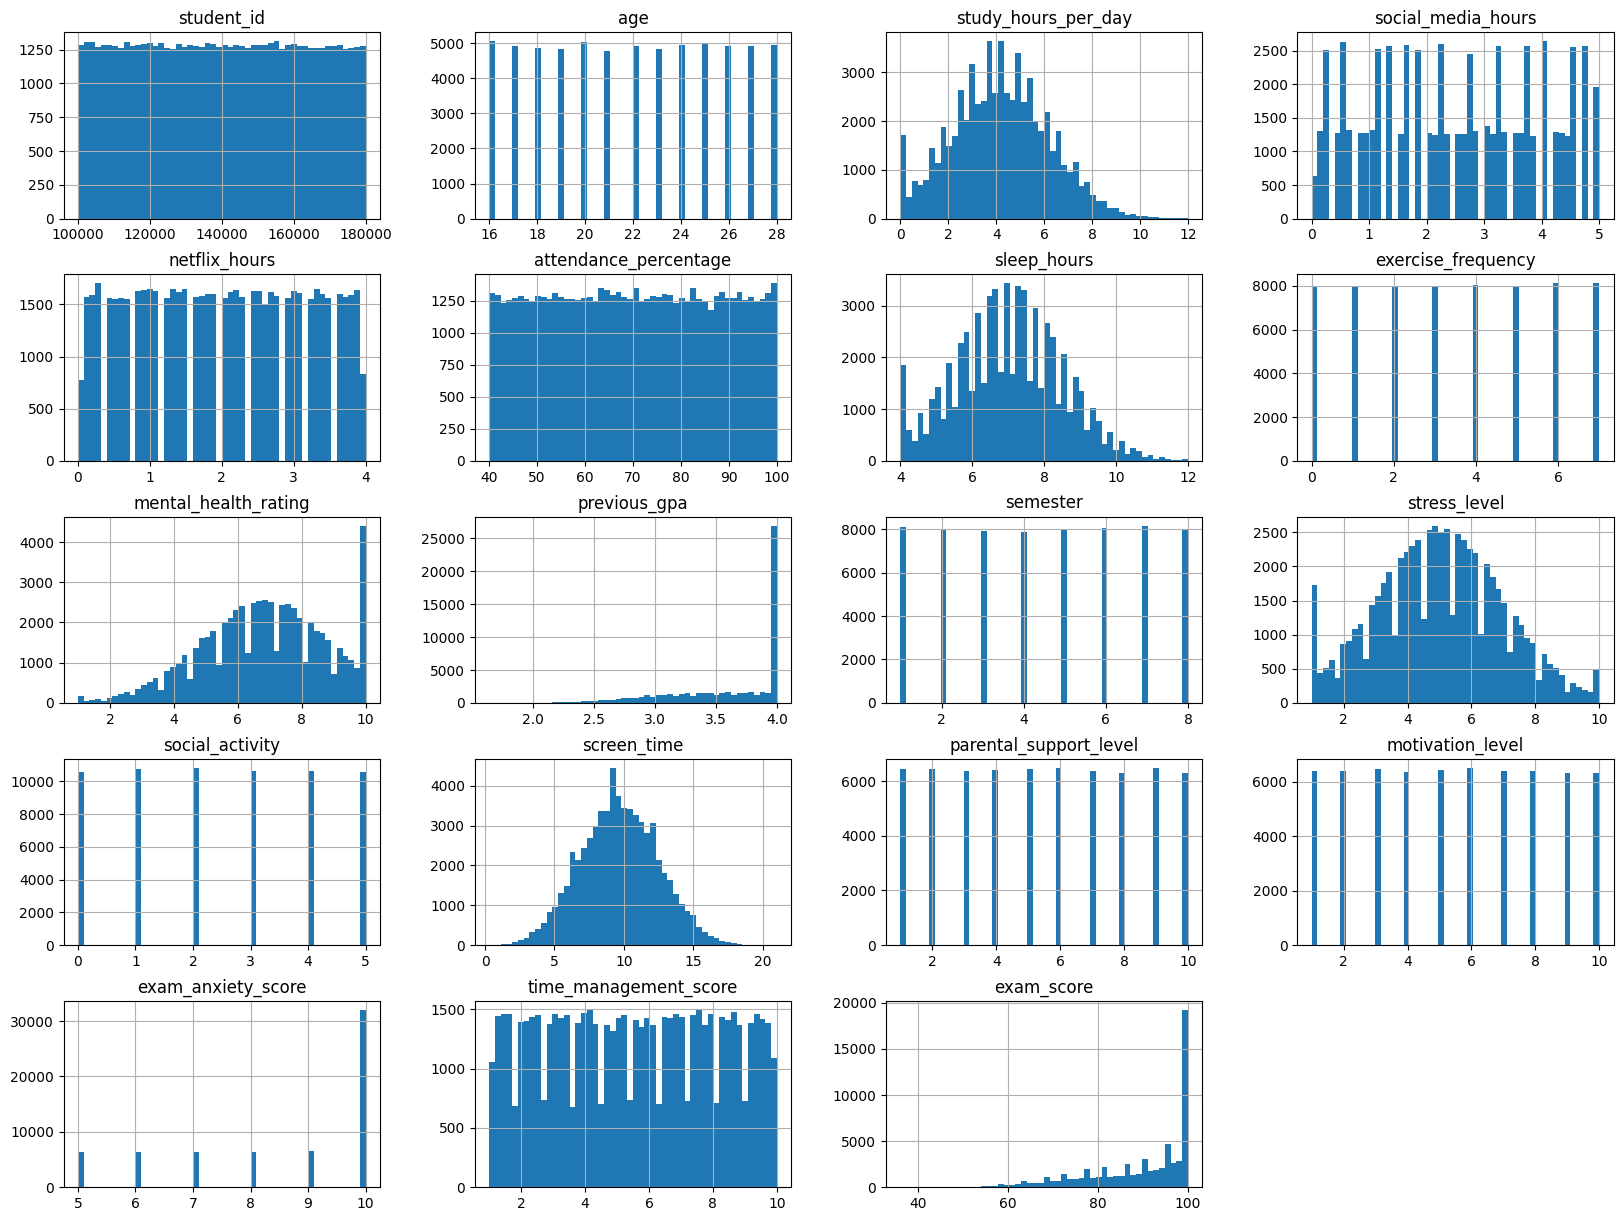

In [56]:
import matplotlib.pyplot as plt
performance_df.hist(bins=50, figsize=(20,15))
plt.show()

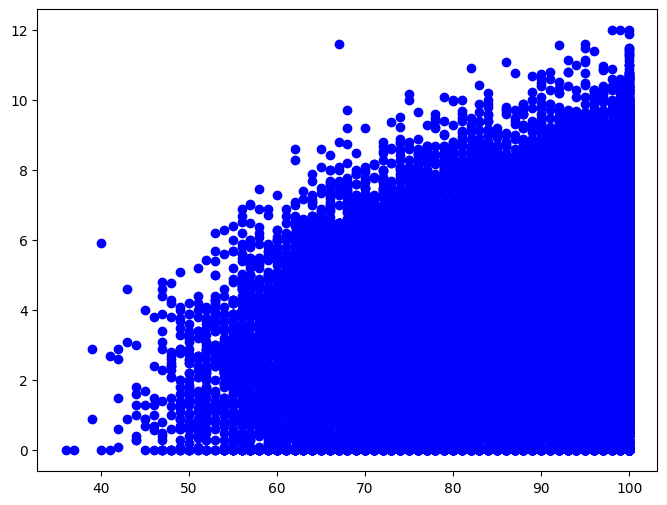

In [55]:
correlation = performance_df["exam_score"].corr(performance_df["study_hours_per_day"])
plt.figure(figsize=(8, 6))
plt.scatter(performance_df["exam_score"], performance_df["study_hours_per_day"], color='blue', label=f'Correlation: r={correlation:.2f}')

In [61]:
performance_df.select_dtypes('object')

,gender,major,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation,dropout_risk,study_environment,access_to_tutoring,family_income_range,learning_style
49477,Male,Business,No,Good,Some College,Low,No,No,Cafe,Yes,Low,Visual
20822,Male,Computer Science,No,Poor,Bachelor,Low,No,No,Library,No,High,Visual
2001,Male,Psychology,Yes,Good,Some College,High,No,No,Library,No,Medium,Reading
8677,Other,Computer Science,Yes,Good,PhD,High,Yes,No,Co-Learning Group,No,Low,Kinesthetic
30335,Female,Computer Science,No,Good,Master,Low,No,No,Library,Yes,Low,Auditory
...,...,...,...,...,...,...,...,...,...,...,...,...
22340,Male,Engineering,Yes,Good,PhD,High,No,No,Dorm,Yes,Medium,Reading
3387,Other,Engineering,No,Poor,High School,Low,Yes,No,Co-Learning Group,Yes,Medium,Reading
33824,Other,Psychology,Yes,Good,PhD,Low,Yes,No,Co-Learning Group,Yes,High,Reading
57236,Other,Arts,No,Good,Bachelor,High,Yes,No,Cafe,Yes,Low,Kinesthetic


In [63]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
text_col = ['gender','major','part_time_job' ,'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation', 'dropout_risk', 'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style']
performance_df[text_col] =encoder.fit_transform(performance_df[text_col])

In [65]:
corr_matrix = performance_df.corr()
corr_matrix["exam_score"].sort_values(ascending=False)

exam_score                       1.000000
previous_gpa                     0.932989
motivation_level                 0.248665
study_hours_per_day              0.241677
screen_time                      0.169360
access_to_tutoring               0.121849
sleep_hours                      0.093272
exercise_frequency               0.085765
study_environment                0.063264
mental_health_rating             0.012786
major                            0.008794
student_id                       0.007705
time_management_score            0.005664
gender                           0.004848
extracurricular_participation    0.002886
attendance_percentage            0.002253
age                              0.002186
internet_quality                 0.002054
semester                         0.000077
netflix_hours                   -0.002056
learning_style                  -0.002818
parental_education_level        -0.003071
part_time_job                   -0.003546
family_income_range             -0